# Baseline Vision Transformer

This notebook contains the baseline experiment for the Fashion-MNIST classification project.

It implements a standard Vision Transformer (ViT) without the CNN feature extractor, advanced data augmentation, or modified training strategy used in the final hybrid model.

### Baseline Results

- **Test accuracy:** 83.80%
- **Training epochs:** 10
- **Training time:** 325.86 minutes
- **Hardware:** CPU

The baseline model provides the reference point for evaluating the improvements introduced in the final hybrid CNN–Vision Transformer model.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import ViTForImageClassification, ViTConfig
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [3]:
# Training settings
batch_size = 128
learning_rate = 0.001
num_epochs = 10  # Start with 10, can increase later
num_classes = 10

print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Number of epochs: {num_epochs}")

Batch size: 128
Learning rate: 0.001
Number of epochs: 10


In [4]:
# Data preprocessing 
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")# Configure Vision Transformer

Training batches: 469
Test batches: 79


In [5]:
# Configure Vision Transformer
config = ViTConfig(
    image_size=32,           # Input image size
    patch_size=4,            # Divide image into 4x4 patches
    num_channels=1,          # Grayscale (Fashion-MNIST is grayscale)
    num_labels=num_classes,  # 10 clothing categories
    hidden_size=256,         # Size of embeddings
    num_hidden_layers=6,     # Number of transformer blocks
    num_attention_heads=8,   # Attention heads per block
    intermediate_size=512    # Size of feed-forward layer
)

# Create model
model = ViTForImageClassification(config)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel has {total_params/1e6:.2f}M parameters")
print("Model created successfully!")


Model has 3.19M parameters
Model created successfully!


In [6]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Loss function: Cross Entropy")
print("Optimizer: Adam")

Loss function: Cross Entropy
Optimizer: Adam


In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [8]:
def evaluate(model, loader, criterion, device):
    """Evaluate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [9]:
# Store results
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    # Store results
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Print results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

end_time = time.time()
training_time = (end_time - start_time) / 60
print(f"\n{'='*60}")
print(f"Training completed in {training_time:.2f} minutes")
print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")
print(f"{'='*60}")


STARTING TRAINING

Epoch 1/10
----------------------------------------


Evaluating: 100%|███████████████████████████████| 79/79 [01:09<00:00,  1.14it/s]


Train Loss: 0.9191 | Train Acc: 65.60%
Test Loss: 0.5922 | Test Acc: 79.04%

Epoch 2/10
----------------------------------------


Evaluating: 100%|███████████████████████████████| 79/79 [01:07<00:00,  1.18it/s]


Train Loss: 0.5561 | Train Acc: 80.07%
Test Loss: 0.6099 | Test Acc: 78.01%

Epoch 3/10
----------------------------------------


...

Train Loss: 0.5053 | Train Acc: 81.64%
Test Loss: 0.5888 | Test Acc: 78.18%

Epoch 9/10
----------------------------------------


Evaluating: 100%|███████████████████████████████| 79/79 [01:20<00:00,  1.02s/it]


Train Loss: 0.5143 | Train Acc: 81.21%
Test Loss: 0.5124 | Test Acc: 81.22%

Epoch 10/10
----------------------------------------


Evaluating: 100%|███████████████████████████████| 79/79 [02:09<00:00,  1.64s/it]

Train Loss: 0.4505 | Train Acc: 83.50%
Test Loss: 0.4421 | Test Acc: 83.80%

Training completed in 325.86 minutes
Final Test Accuracy: 83.80%


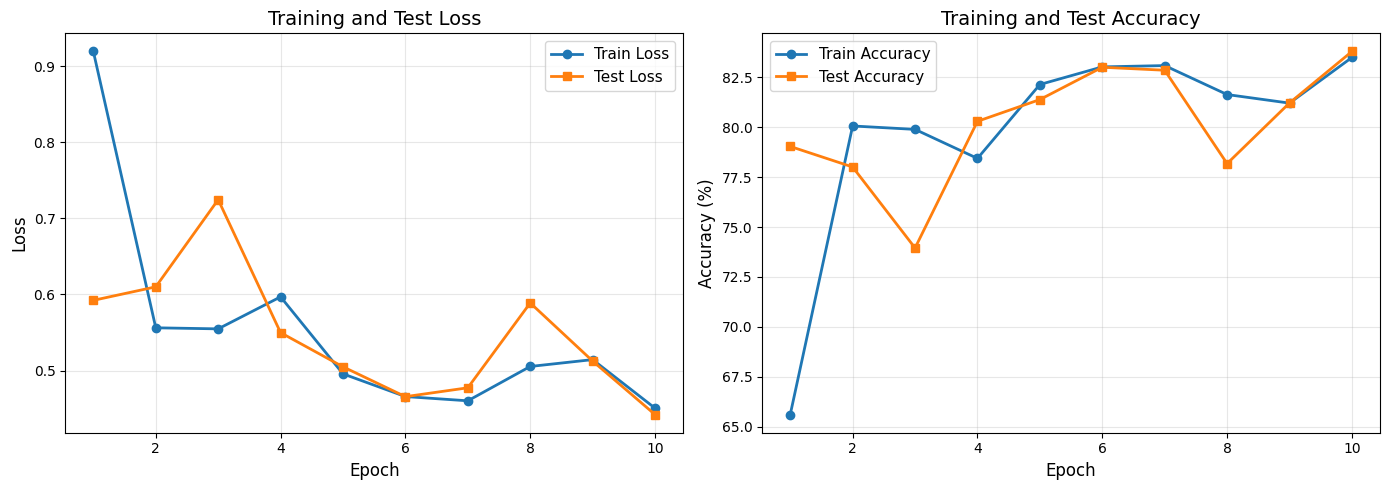

Best Test Accuracy: 83.80%


In [10]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, num_epochs+1), train_losses, 'o-', label='Train Loss', linewidth=2)
ax1.plot(range(1, num_epochs+1), test_losses, 's-', label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(range(1, num_epochs+1), train_accs, 'o-', label='Train Accuracy', linewidth=2)
ax2.plot(range(1, num_epochs+1), test_accs, 's-', label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best Test Accuracy: {max(test_accs):.2f}%")

In [12]:
# Save model
torch.save(model.state_dict(), 'baseline_vit_model.pth')
print("Baseline model saved as 'baseline_vit_model.pth'")

# Save training history
import pickle
history = {
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs
}
with open('baseline_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print("Training history saved as 'baseline_history.pkl'")

Baseline model saved as 'baseline_vit_model.pth'
Training history saved as 'baseline_history.pkl'
